In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import pandas as pd

from src.cleaning import (
    camel_to_snake,
    missing_values_table,
    plot_boxplots_grid,
    reorder_cols,
)

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT = Path("../..")

RAW_DATA_PATH = PROJECT_ROOT / "data/raw/phishing/PhishingURLPhiUSIIL.csv"
DTYPES_PATH = PROJECT_ROOT / "references/DTYPES_PhishingURLPhiUSIIL.json"

CLEANED_DATA_PATH = PROJECT_ROOT / "data/cleaned"

# Loading Data

First, let's load the file and have an overview of data to make sure what steps we need in order to clean the dataset


In [3]:
with DTYPES_PATH.open("r") as file:
    dtypes = json.load(file)

df = pd.read_csv(RAW_DATA_PATH, dtype=dtypes)
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,TargetIsPhishing
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,False,com,100.0,1.000000,0.522907,0.061933,3,1,False,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,True,558,9381,True,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,False,True,True,0,0,False,0,1,False,False,True,True,False,True,False,False,True,34,20,28,119,0,124,True
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,False,de,100.0,0.666667,0.032650,0.050207,2,1,False,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,True,618,9381,True,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,True,True,False,0,0,False,0,0,False,True,True,False,False,False,False,False,True,50,9,8,39,0,217,True
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,False,uk,100.0,0.866667,0.028555,0.064129,2,2,False,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,True,467,682,True,voice fm southampton,46.666667,46.666667,False,True,True,0,0,True,0,0,False,False,True,True,False,False,False,False,True,10,2,7,42,2,5,True
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,False,com,100.0,1.000000,0.522907,0.057606,3,1,False,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,True,6356,26824,True,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,False,True,True,0,0,False,1,12,False,True,True,True,False,False,True,True,True,3,27,15,22,1,31,True
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,False,org,100.0,1.000000,0.079963,0.059441,3,1,False,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,True,6089,28404,True,fundaciÃ³n rewilding argentina,100.000000,100.000000,False,True,True,1,1,True,0,2,False,True,True,True,False,True,True,False,True,244,15,34,72,1,85,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  string 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  string 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  boolean
 5   TLD                         235795 non-null  string 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  boolean
 13  NoOfObfuscatedChar       

# Index, column names and dtypes

As we done in the last notebook, we can extract some insights:

* We can use `url` as an index since it identifies each row uniquely (and is the object of the study)
* All boolean columns are defined as integeres (0 and 1), we can convert this to boolean;
* There are no missing values in any column

So, we are going to do similar changes that we done in the last section. This is, setting an index, convert the types,
reorder columns. We are also going to use an additional file that contains the DTYPES 
[`references/DTYPES_PhishingURLPhiUSIIL.json`](../../references/DTYPES_PhishingURLPhiUSIIL.json).

In [5]:
df.columns = [camel_to_snake(x) for x in df.columns]
df = df[reorder_cols(cols=list(df.columns), pk="url", target="target_is_phishing")]
df = df.set_index("url")
df.head()

,bank,char_continuation_rate,crypto,degit_ratio_in_url,domain,domain_length,domain_title_match_score,has_copyright_info,has_description,has_external_form_submit,has_favicon,has_hidden_fields,has_obfuscation,has_password_field,has_social_net,has_submit_button,has_title,is_domain_ip,is_https,is_responsive,largest_line_length,letter_ratio_in_url,line_of_code,no_of_ampersand_in_url,no_of_css,no_of_degits_in_url,no_of_empty_ref,no_of_equals_in_url,no_of_external_ref,no_of_image,no_of_js,no_of_letters_in_url,no_of_obfuscated_char,no_of_other_special_chars_in_url,no_of_popup,no_of_q_mark_in_url,no_of_self_redirect,no_of_self_ref,no_of_sub_domain,no_of_url_redirect,no_ofi_frame,obfuscation_ratio,pay,robots,spacial_char_ratio_in_url,title,tld,tld_legitimate_prob,tld_length,url_char_prob,url_length,url_similarity_index,url_title_match_score,target_is_phishing
url,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
https://www.southbankmosaics.com,True,1.000000,False,0.0,www.southbankmosaics.com,24,0.000000,True,False,False,False,True,False,False,False,True,True,False,True,True,9381,0.581,558,0,20,0,0,0,124,34,28,18,0,1,0,0,0,119,1,0,1,0.0,False,True,0.032,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,com,0.522907,3,0.061933,31,100.0,0.000000,True
https://www.uni-mainz.de,False,0.666667,False,0.0,www.uni-mainz.de,16,55.555556,True,False,False,True,False,False,False,True,True,True,False,True,False,9381,0.391,618,0,9,0,0,0,217,50,8,9,0,2,0,0,0,39,1,0,0,0.0,False,True,0.087,johannes gutenberg-universitÃ¤t mainz,de,0.032650,2,0.050207,23,100.0,55.555556,True
https://www.voicefmradio.co.uk,False,0.866667,False,0.0,www.voicefmradio.co.uk,22,46.666667,True,True,False,False,True,False,False,False,True,True,False,True,True,682,0.517,467,0,2,0,2,0,5,10,7,15,0,2,0,0,0,42,2,0,0,0.0,False,True,0.069,voice fm southampton,uk,0.028555,2,0.064129,29,100.0,46.666667,True
https://www.sfnmjournal.com,False,1.000000,True,0.0,www.sfnmjournal.com,19,0.000000,True,False,False,False,True,False,False,True,True,True,False,True,True,26824,0.500,6356,0,27,0,1,0,31,3,15,13,0,1,1,0,0,22,1,0,12,0.0,True,True,0.038,home page: seminars in fetal and neonatal medi...,com,0.522907,3,0.057606,26,100.0,0.000000,True
https://www.rewildingargentina.org,True,1.000000,False,0.0,www.rewildingargentina.org,26,100.000000,True,True,False,False,True,False,False,True,True,True,False,True,True,28404,0.606,6089,0,15,0,1,0,85,244,34,20,0,1,0,0,1,72,1,1,2,0.0,True,True,0.030,fundaciÃ³n rewilding argentina,org,0.079963,3,0.059441,33,100.0,100.000000,True


# Duplicated columns

Now, let's take a look into duplicated values

In [6]:
df[df.duplicated(keep=False)].sort_index()

,bank,char_continuation_rate,crypto,degit_ratio_in_url,domain,domain_length,domain_title_match_score,has_copyright_info,has_description,has_external_form_submit,has_favicon,has_hidden_fields,has_obfuscation,has_password_field,has_social_net,has_submit_button,has_title,is_domain_ip,is_https,is_responsive,largest_line_length,letter_ratio_in_url,line_of_code,no_of_ampersand_in_url,no_of_css,no_of_degits_in_url,no_of_empty_ref,no_of_equals_in_url,no_of_external_ref,no_of_image,no_of_js,no_of_letters_in_url,no_of_obfuscated_char,no_of_other_special_chars_in_url,no_of_popup,no_of_q_mark_in_url,no_of_self_redirect,no_of_self_ref,no_of_sub_domain,no_of_url_redirect,no_ofi_frame,obfuscation_ratio,pay,robots,spacial_char_ratio_in_url,title,tld,tld_legitimate_prob,tld_length,url_char_prob,url_length,url_similarity_index,url_title_match_score,target_is_phishing
url,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
http://s.id/vstaerr,False,1.000000,False,0.000,s.id,4,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,27,0.500,2,0,0,0,0,0,0,0,0,9,0,2,0,0,0,0,0,0,0,0.0,False,False,0.111,0,id,0.001465,2,0.055978,18,55.096419,0.0,False
http://s.id/vstearr,False,1.000000,False,0.000,s.id,4,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,27,0.500,2,0,0,0,0,0,0,0,0,9,0,2,0,0,0,0,0,0,0,0.0,False,False,0.111,0,id,0.001465,2,0.055978,18,55.096419,0.0,False
https://connection-orangebank-certicode.derlma.com/2375489/,True,0.289474,False,0.119,connection-orangebank-certicode.derlma.com,42,0.0,False,False,False,False,False,False,False,False,False,False,False,True,False,67,0.644,2,0,0,7,0,0,0,0,0,38,0,6,0,0,0,0,1,0,0,0.0,False,False,0.102,0,com,0.522907,3,0.057333,59,38.352941,0.0,False
https://connection-orangebank-certicode.derlma.com/2385947/,True,0.289474,False,0.119,connection-orangebank-certicode.derlma.com,42,0.0,False,False,False,False,False,False,False,False,False,False,False,True,False,67,0.644,2,0,0,7,0,0,0,0,0,38,0,6,0,0,0,0,1,0,0,0.0,False,False,0.102,0,com,0.522907,3,0.057333,59,38.352941,0.0,False
https://connection-orangebank-certicode.derlma.com/2398745/,True,0.289474,False,0.121,connection-orangebank-certicode.derlma.com,42,0.0,False,False,False,False,False,False,False,False,False,False,False,True,False,67,0.655,2,0,0,7,0,0,0,0,0,38,0,5,0,0,0,0,1,0,0,0.0,False,False,0.086,0,com,0.522907,3,0.057333,58,38.352941,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
https://moncar.com.mx/package/bibaztgkmv4352/,False,0.700000,False,0.091,moncar.com.mx,13,0.0,True,False,False,True,False,False,False,False,True,False,False,True,True,225,0.636,246,0,4,4,0,0,3,4,4,28,0,4,0,0,0,0,1,0,0,0.0,False,False,0.091,0,mx,0.001722,2,0.047103,44,28.787120,0.0,False
https://moncar.com.mx/package/bibaztgkmv4377/,False,0.700000,False,0.089,moncar.com.mx,13,0.0,True,False,False,True,False,False,False,False,True,False,False,True,True,225,0.622,246,0,4,4,0,0,3,4,4,28,0,5,0,0,0,0,1,0,0,0.0,False,False,0.111,0,mx,0.001722,2,0.047056,45,28.787120,0.0,False
https://moncar.com.mx/package/bibaztgkmv4523/,False,0.700000,False,0.091,moncar.com.mx,13,0.0,True,False,False,True,False,False,False,False,True,False,False,True,True,225,0.636,246,0,4,4,0,0,3,4,4,28,0,4,0,0,0,0,1,0,0,0.0,False,False,0.091,0,mx,0.001722,2,0.047103,44,28.787120,0.0,False


As you can see we have some cases of duplicated values in the dataset:

**Case 01: `s.id/vstaerr`**

The entries have the same URL and values for the other columns. We can drop them since they represent the same thing.

**Case 02: `connection-orangebank-certicode.derlma.com`**

A different kind of duplication here, in this case all the URLs starts the same, however we have a different 7-digit
number in the path of the URL. Since the exact URL is not important to the dataset, this is, the different numbers does
not impact the variables of the dataset, only the index we can keep only one case.

**Case 03: `moncar.com.mx`**

Is the same as the Case 2, only changing the pattern of the entries. The difference is a 4-digit number at the end of 
the URL. So, we are also going to keep only one

In [7]:
df = df.drop_duplicates()

# Missing data

As analyzed before and confirmed here, there are no missing values in the dataset. So, we can skip this step

In [8]:
missing_values_table(df)

,% missing,# total,# missing
bank,0.0,235704,0
char_continuation_rate,0.0,235704,0
crypto,0.0,235704,0
degit_ratio_in_url,0.0,235704,0
domain,0.0,235704,0
domain_length,0.0,235704,0
domain_title_match_score,0.0,235704,0
has_copyright_info,0.0,235704,0
has_description,0.0,235704,0
has_external_form_submit,0.0,235704,0


# Columns Analysis

Now we are going to analyze all the columns based on their types and look for any problem that they might have.

In [9]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"], exclude=["boolean"]
).columns.tolist()
print(f"Numerical: {numerical_cols}")  # noqa: T201

boolean_cols = df.select_dtypes(include=["boolean"]).columns.tolist()
print(f"Boolean:   {boolean_cols}")  # noqa: T201

string_cols = df.select_dtypes(include=["string"]).columns.tolist()
print(f"String:    {string_cols}")  # noqa: T201

Numerical: ['char_continuation_rate', 'degit_ratio_in_url', 'domain_length', 'domain_title_match_score', 'largest_line_length', 'letter_ratio_in_url', 'line_of_code', 'no_of_ampersand_in_url', 'no_of_css', 'no_of_degits_in_url', 'no_of_empty_ref', 'no_of_equals_in_url', 'no_of_external_ref', 'no_of_image', 'no_of_js', 'no_of_letters_in_url', 'no_of_obfuscated_char', 'no_of_other_special_chars_in_url', 'no_of_popup', 'no_of_q_mark_in_url', 'no_of_self_redirect', 'no_of_self_ref', 'no_of_sub_domain', 'no_of_url_redirect', 'no_ofi_frame', 'obfuscation_ratio', 'spacial_char_ratio_in_url', 'tld_legitimate_prob', 'tld_length', 'url_char_prob', 'url_length', 'url_similarity_index', 'url_title_match_score']
Boolean:   ['bank', 'crypto', 'has_copyright_info', 'has_description', 'has_external_form_submit', 'has_favicon', 'has_hidden_fields', 'has_obfuscation', 'has_password_field', 'has_social_net', 'has_submit_button', 'has_title', 'is_domain_ip', 'is_https', 'is_responsive', 'pay', 'robots', '

### Numerical

For the numerical case we are going to plot some boxplots in order to analyze if there is any outliers that looks like
a problem. For example, we can assume that a URL cannot have a negative domain length. If something seems off we can
individually investigate the cases.

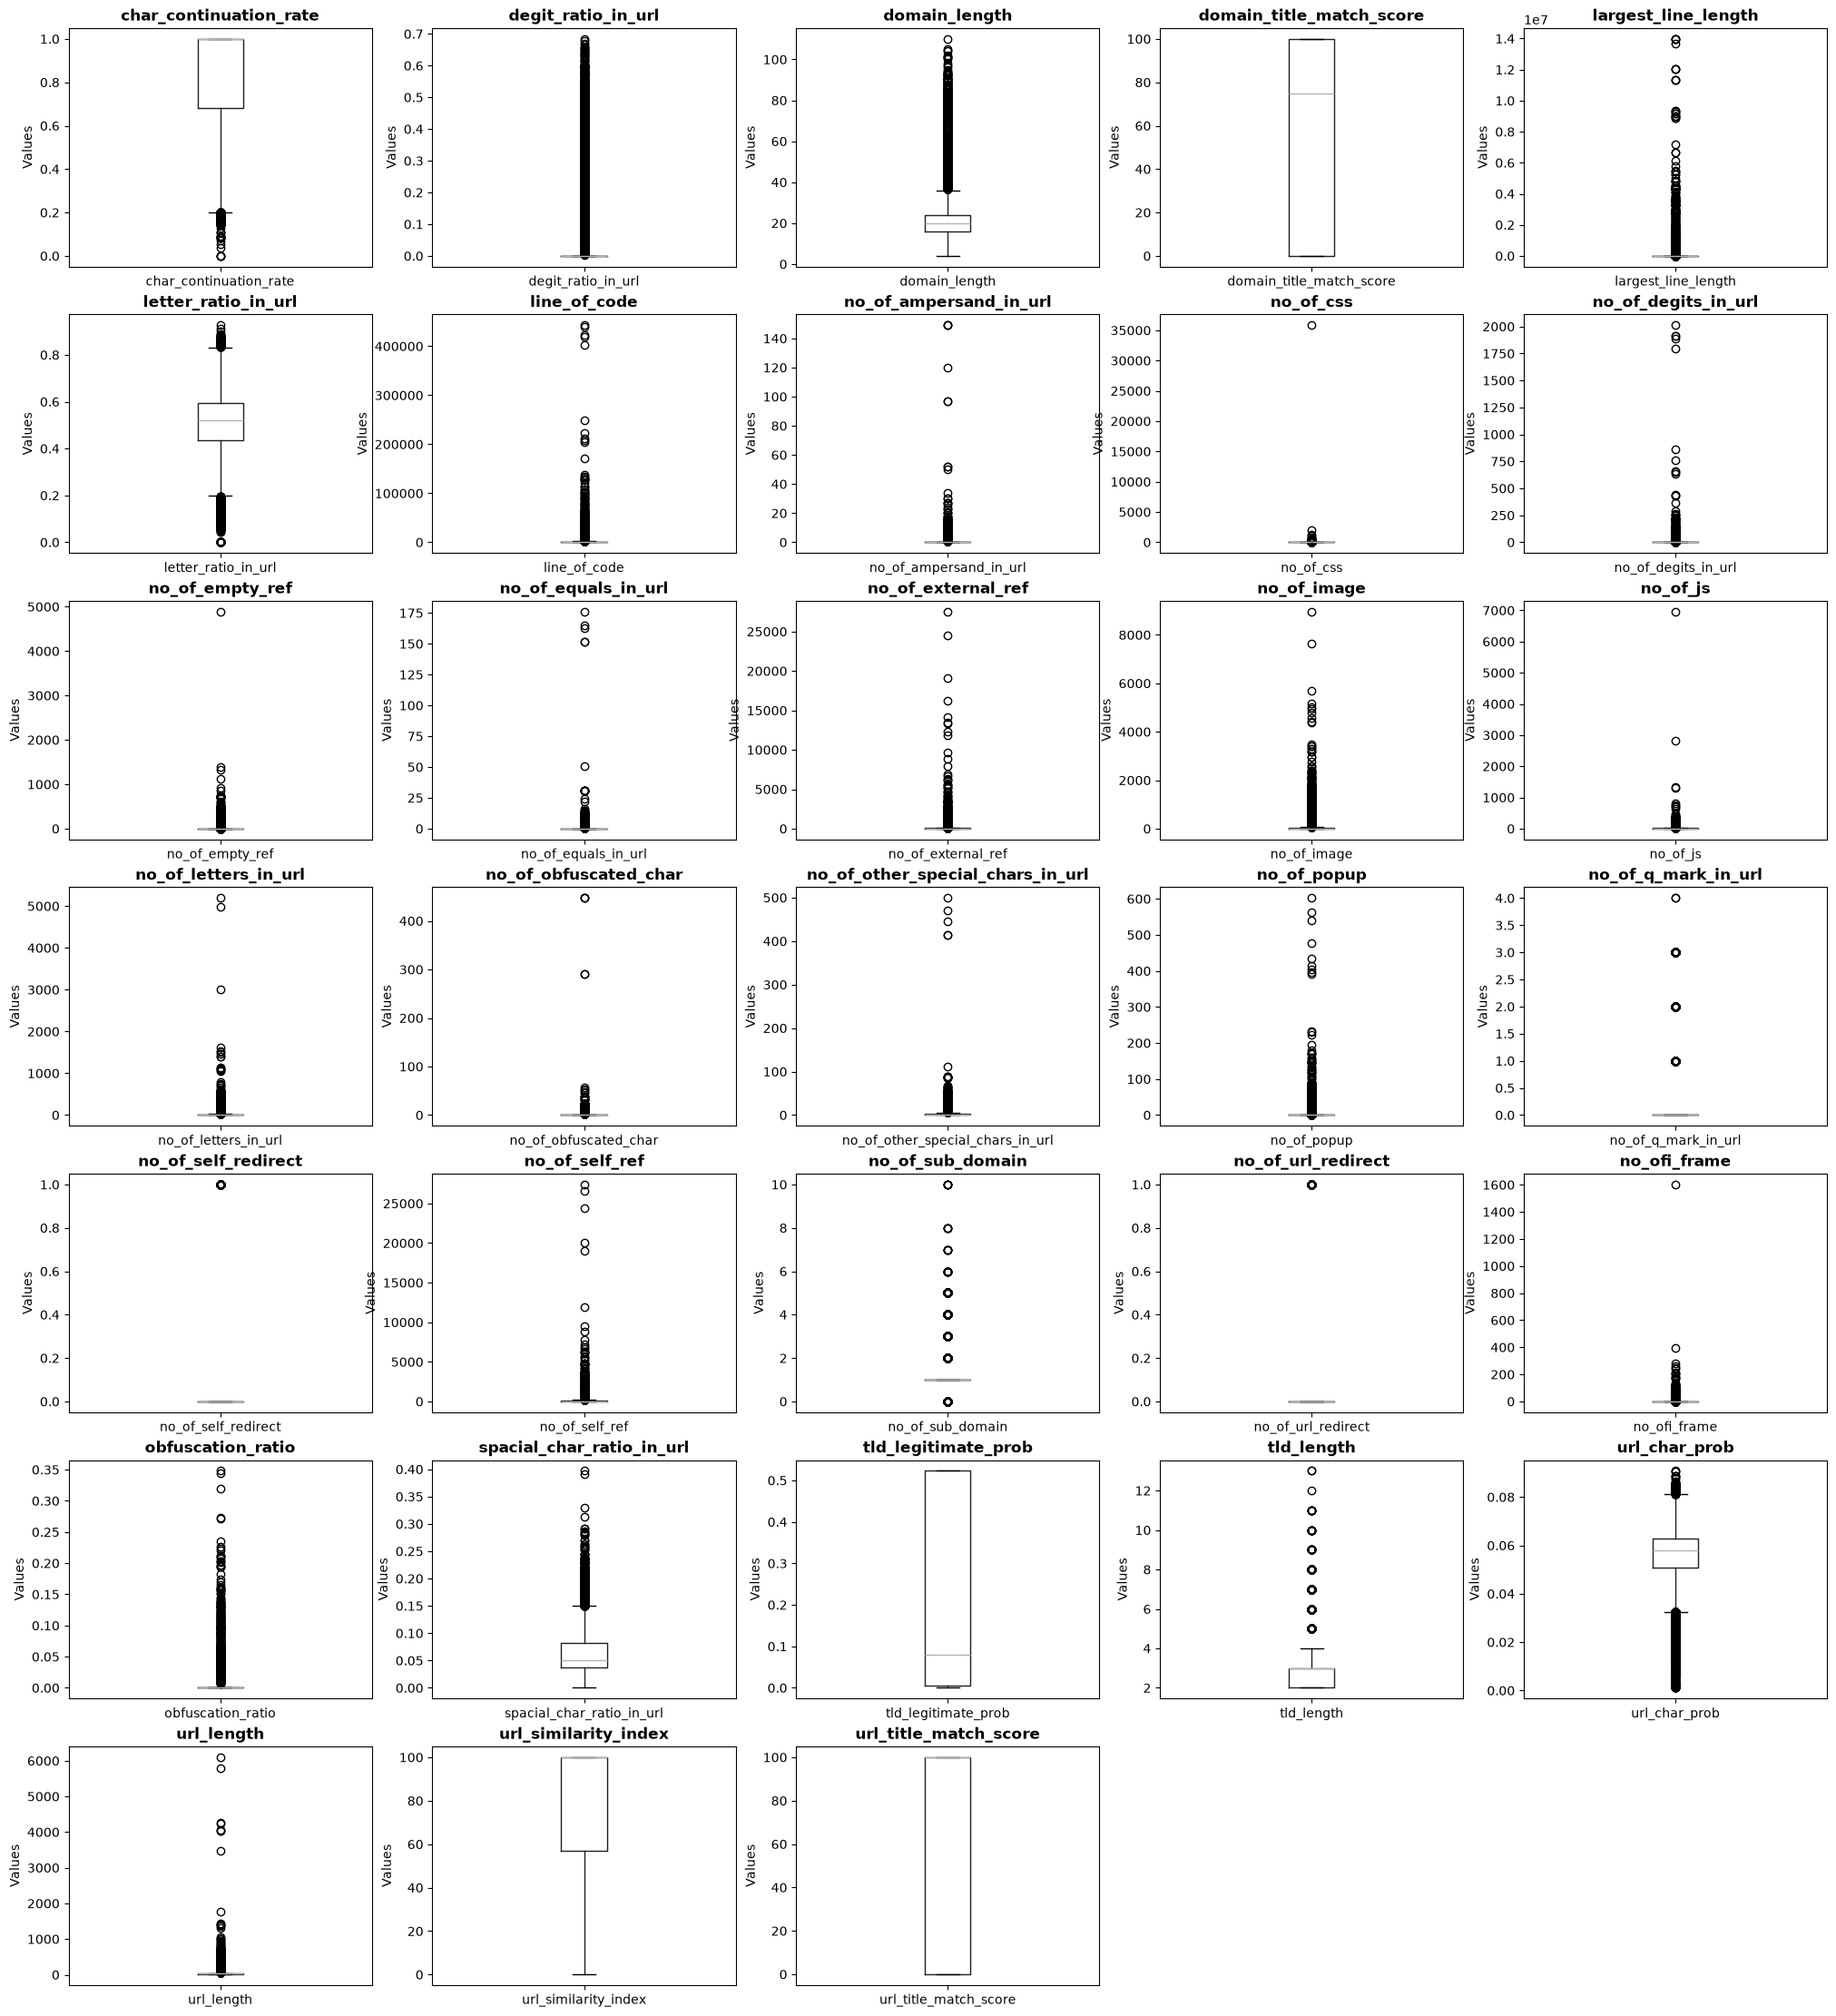

In [16]:
plot_boxplots_grid(df, numerical_cols, 5);

Based on the boxplots above, there isn't anything that looks like a problem. We can see the presence of really long 
URLs that affect the variables that are impacted by the number of characters (e.g. domain_length, largest_line_length
no_of_letters, and so on.). We are going to take a look on these big URLs just to see if there is anything that seems
odd.

In [11]:
df.sort_values(by="url_length", ascending=False).head(50)

bank  \
url                                                         
https://xwebhostapp.github.io/freehost//#eyj2zx...  False   
https://b4e921f0.sso-mailsrvr-4344e5teed.pages....  False   
https://bodhicardstech.com/beta/wx%20qz%20xx%20...  False   
https://inspirationalatmospheres.com/qxzrrr%20r...  False   
https://bodhicardstech.com/beta/wx%20qz%20xx%20...   True   
http://www.inspirationalatmospheres.com/qxzrrr%...   True   
https://inspirationalatmospheres.com/qxzrrr%20r...   True   
https://ssiol.lt.emlnk.com/prod/link-tracker?no...  False   
https://ssiol.lt.emlnk.com/prod/link-tracker?no...  False   
https://u31696126.ct.sendgrid.net/ls/click?upn=...  False   
https://u32226201.ct.sendgrid.net/ls/click?upn=...  False   
https://00f74ba44be8f9b9bb3411da8750379890c6c72...  False   
https://00f74ba44b3bbdac8099a208fad8bc80ecfd56c...  False   
https://00f74ba44baef2a33a53f6faa85c0cd3256e3b0...  False   
https://u32226201.ct.sendgrid.net/ls/click?upn=...  False   
https://xpc.tasikfoods.com/a/vumraztouxkjrhm260...  False   
https://ipfs.io/ipfs/qmvv17ugiq8tk7qwcusmepxsd1...  False   
https://ad-obsproject.com/out.html?oauth20_auth...  False   
https://ipfs.io/ipfs/qmxvhjrwpe3xtebanyhnvwcukq...  False   
https://xjautx-gaucz45evq-uc.a.run.app/https://...   True   
https://tracking.selfserviceib.com/tracking/1/c...  False   
https://effective-design.com/mace-03-02-b72qfwk...  False   
https://ipfs.io/ipfs/qmyp9y8vszbvkqxtejw1ijhs7v...  False   
https://trk.klclick3.com/ls/click?upn=hy-2bfbhq...  False   
https://login.shellnavcontrol.com/common/oauth2...  False   
https://d39wpm04.eu1.hubspotlinksstarter.com/ct...  False   
http://barnetfcacademy.c86604l.xyz/common/oauth...  False   
https://tracking.selfserviceib.com/tracking/1/c...  False   
https://betaniho.com/cma4l4k.php?key=5x0xmnke9w...  False   
https://u33635890.ct.sendgrid.net/ls/click?upn=...  False   
https://u32547931.ct.sendgrid.net/ls/click?upn=...  False   
https://docs.google.com/presentation/d/e/2pacx-...  False   
https://lps.onevoda.com/rsta_clc_es_gt_onv/?coc...  False   
https://lps.onevoda.com/chzp_clc_es_gt_onv/?coc...  False   
https://lps.onevoda.com/mjud_clc_es_gt_onv/?coc...  False   
https://www.attemplate.com/eur/68283f3b-8487-4c...  False   
https://www.sharestion.com/nam/be0f980b-dd99-4b...  False   
https://www.prizegives.com/apc/63ce7d59-2f3e-42...  False   
https://www.attemplate.com/nam/be0f980b-dd99-4b...  False   
https://www.officested.com/nam/25a51937-6bbd-46...  False   
https://www.prizewel.com/nam/72f988bf-86f1-41af...  False   
https://u32981963.ct.sendgrid.net/ls/click?upn=...  False   
https://u32400465.ct.sendgrid.net/ls/click?upn=...  False   
https://www.attemplate.com/nam/be0f980b-dd99-4b...  False   
https://www.attemplate.com/aus/57644f34-60a9-42...  False   
https://www.attemplate.com/eur/9179d01a-e94c-44...  False   
https://www.attemplate.com/nam/be0f980b-dd99-4b...  False   
https://www.attemplate.com/nam/be0f980b-dd99-4b...  False   
https://www.attemplate.com/deu/f65d2ccc-60c0-4c...  False   
https://www.attemplate.com/nam/be0f980b-dd99-4b...  False   

                                                    char_continuation_rate  \
url                                                                          
https://xwebhostapp.github.io/freehost//#eyj2zx...                0.666667   
https://b4e921f0.sso-mailsrvr-4344e5teed.pages....                0.342105   
https://bodhicardstech.com/beta/wx%20qz%20xx%20...                1.000000   
https://inspirationalatmospheres.com/qxzrrr%20r...                1.000000   
https://bodhicardstech.com/beta/wx%20qz%20xx%20...                1.000000   
http://www.inspirationalatmospheres.com/qxzrrr%...                1.000000   
https://inspirationalatmospheres.com/qxzrrr%20r...                1.000000   
https://ssiol.lt.emlnk.com/prod/link-tracker?no...                0.428571   
https://ssiol.lt.emlnk.com/prod/link-tracker?no...                0.428571   
https://u31696126.ct.s

As you can see, the URLs are really long but there is no apparent problem in them. So we should keep this data.

### Boolean

For the boolean columns, since we already converted the data types in the beginning, we are only going to double-check if all the booleans are correctly defined

In [12]:
boolean_cols

['bank',
 'crypto',
 'has_copyright_info',
 'has_description',
 'has_external_form_submit',
 'has_favicon',
 'has_hidden_fields',
 'has_obfuscation',
 'has_password_field',
 'has_social_net',
 'has_submit_button',
 'has_title',
 'is_domain_ip',
 'is_https',
 'is_responsive',
 'pay',
 'robots',
 'target_is_phishing']

### Categorical

There are no real categorical variables in the dataset. The closest one is `tld` that does not have a lot of options.
Let's take a look on that

In [13]:
print(list(df.tld.unique()))  # noqa: T201

['com', 'de', 'uk', 'org', 'in', 'ie', 'hu', 'ru', 'gq', 'es', 'jp', 'guru', 'app', 'io', 'club', 'fr', 'au', 'today', 'cloud', 'br', 'pt', 'co', 'lt', 'ca', 'xyz', 'sk', 'pl', 'dk', 'dev', 'ga', 'edu', 'space', 'ws', '123', 'cf', 'rs', 'games', 'nl', 'me', 'net', 'life', 'ua', 'id', 'mx', 'asia', 'store', 'nz', 'eus', 'qa', 'fi', 'ch', 'site', 'shop', 'hr', 'cz', 'im', 'ee', 'sg', 'travel', 'tz', 'top', 'info', 'tokyo', 'at', 'gr', 'cc', 'tv', 'online', 'lk', 'review', 'us', 'bar', 'link', 'ng', 'cl', 'ar', 'one', 'ph', 'tr', 'mil', 'se', '94', 'live', 'cn', 'ir', 'it', 'gd', 'eu', 'win', 'no', 'su', 'gov', 'bg', 'ro', 'kr', 'eg', 'biz', 'il', 'page', 'pm', 'sh', 'pk', 'my', 'quest', 'be', 'sa', 'tk', 'vip', 'agency', 'cyou', 'kz', 'uy', 'network', '128', 'ml', 'hk', 'media', 'az', 'aero', 'news', 'lu', 'is', 'coop', 'art', 'download', 'si', 'fm', 'bt', 'am', 'finance', 'mn', 'kh', 'ug', 'ae', 'cool', 'za', 'th', 'energy', 'lv', 'global', 'tw', 'ke', 'moe', 'icu', '103', 'fun', '130',

As you can also see. There aren't any value that seems to be an error. So, there is nothing to do here

# Saving the Data

With all the data cleaned. We can save it to use in the next phases of this project

In [14]:
df.to_parquet(CLEANED_DATA_PATH / "phishing.parquet")